In [6]:
import pandas as pd
import numpy as np
print("Pandas: ", pd.__version__)
print("NumPy: ", np.__version__)

Pandas:  2.2.2
NumPy:  2.0.2


In [7]:
url = "https://raw.githubusercontent.com/harshitcodes/tmdb_movie_data_analysis/master/tmdb-5000-movie-dataset/tmdb_5000_movies.csv"
df = pd.read_csv(url)

print("Размер загруженного датасета:", df.shape)

Размер загруженного датасета: (4803, 20)


Я решила использовать TMDB 5000 Movie Dataset так как меня интересует тематика.

In [14]:
df.head()


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [15]:
df.describe()
df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

,0
budget,int64
genres,object
homepage,object
id,int64
keywords,object
original_language,object
original_title,object
overview,object
popularity,float64
production_companies,object


4803 строки (фильма)
20 колонок (признаков для каждого фильма)
У большинства признаков стоит 4803 non-null. Это значит, что бюджет, жанры, популярность и сборы заполнены для каждого фильма. Колонка homepage заполнена только у 1712 фильмов. То же самое с tagline. Но ссылки сами по себе не несут ценности. Можно удалить, а можно превратить в отдельный признак есть/нет страница фильма. Этот признак можно использовать если следовать логике что наличие ссылки отражает количество вложенных средств на маркетинг и тд.

Типы
int64 и float64 числа. С бюджетом, сборами, хронометражем и оценками можно сразу делать математические операции.

object это текстовые данные. Названия, описания, жанры и ключевые слова. Их нужно будет обрабатывать текстовыми методами. Это тексты можно векторизировать чтобы проанализировать схожесть фильмов например.

In [18]:
average_rating = df['vote_average'].mean()
print(f"Средний рейтинг: {average_rating}")

Средний рейтинг: 6.092171559442016


Достаточно реалистичное значение. Указывает на нормально распределение оценок и на наличие в выборке достаточного количества фильмов среднего качества.

In [20]:
max_budget = df['budget'].max()
print(max_budget)
min_runtime = df['runtime'].min()
print(min_runtime)


380000000
0.0


В данном случае ноль по длительности это не реальное значение а заглушка (для пропущенных данных). В основом это делают для малоизвестных картин о которых мало информации либо о фильмах со статусом слухов.

In [28]:
zero_runtime_movies = df[df['runtime'] == 0.0]

print("5 фильмов с длительностью 0")
print(zero_runtime_movies[['original_title', 'status', 'release_date', 'budget']].head())

5 фильмов с длительностью 0
               original_title    status release_date   budget
1011          The Tooth Fairy  Released   2006-08-08        0
3112  Blood Done Sign My Name  Released   2010-02-01        0
3669     Should've Been Romeo  Released   2012-04-28        0
3809      How to Fall in Love  Released   2012-07-21  4000000
3953               Fort McCoy  Released   2014-01-01        0


In [30]:
rumored_movies = df[df['status'] == 'Rumored']
print(f"Количество фильмов со статусом слухи: {len(rumored_movies)}\n")
print(rumored_movies[['original_title', 'status', 'release_date', 'budget', 'runtime']])

Количество фильмов со статусом слухи: 5

                original_title   status release_date  budget  runtime
4401       The Helix... Loaded  Rumored   2005-01-01       0     97.0
4453      Crying with Laughter  Rumored   2009-06-01       0     93.0
4508  The Harvest (La Cosecha)  Rumored   2011-07-29   56000     80.0
4662            Little Big Top  Rumored   2006-01-01       0      0.0
4754             The Naked Ape  Rumored   2006-09-16       0    110.0


In [16]:
top_blockbusters = df[(df['budget'] > 100000000) & (df['vote_average'] > 7.5)]
print(top_blockbusters[['original_title', 'budget', 'vote_average']].head())

median_revenue = top_blockbusters['revenue'].median()
print(f"\nМедианная выручка отличных блокбастеров: {median_revenue} $")

                         original_title     budget  vote_average
3                 The Dark Knight Rises  250000000           7.6
22  The Hobbit: The Desolation of Smaug  250000000           7.6
42                          Toy Story 3  200000000           7.6
57                               WALL·E  180000000           7.8
65                      The Dark Knight  185000000           8.2

Медианная выручка отличных блокбастеров: 735099082.0 $


Медианная выручка в данной группе составляет более 735 млн. Картины с высокими производственными бюджетами, получившие высокую оценку зрителей, генерируют высокий объем кассовой выручки. Кому-то покажется common sense, а я скажу что в ад нет ничего очевидного

In [17]:
df['profit'] = df.apply(lambda x: x['revenue'] - x['budget'], axis=1)
top_profitable = df[['original_title', 'budget', 'revenue', 'profit']].sort_values(by='profit', ascending=False)
print(top_profitable.head())

    original_title     budget     revenue      profit
0           Avatar  237000000  2787965087  2550965087
25         Titanic  200000000  1845034188  1645034188
28  Jurassic World  150000000  1513528810  1363528810
44       Furious 7  190000000  1506249360  1316249360
16    The Avengers  220000000  1519557910  1299557910


Данные фильмы являются статистическими аномалиями на фоне медианных показателей рынка. Их объединяет принадлежность к крупным франшизам или масштабный визуал

Выводы

* Средний зрительский рейтинг по выборке составляет около 6.1 балла из 10. Это указывает на реалистичное распределение оценок.

* Нули в числовых признаках часто выступают заглушками для отсутствующей информации, требуя обязательной фильтрации для получения корректной статистики.

* Фильтрация высокобюджетных картин с рейтингом выше 7.5 баллов позволила выделить массовое популярное кино. Их медианные сборы превышают 735 млн, что подтверждает их статус безопасных рекомендаций для рпользователя (для рекомендательной сисетмы например)

* Расчет абсолютной разницы между сборами и бюджетом показал, что абсолютные лидеры проката генерируют валовую разницу от 1.3 до 2.5 млрд. С точки зрения машинного обучения эти картины являются аномалиями, что потребует учета в будущем

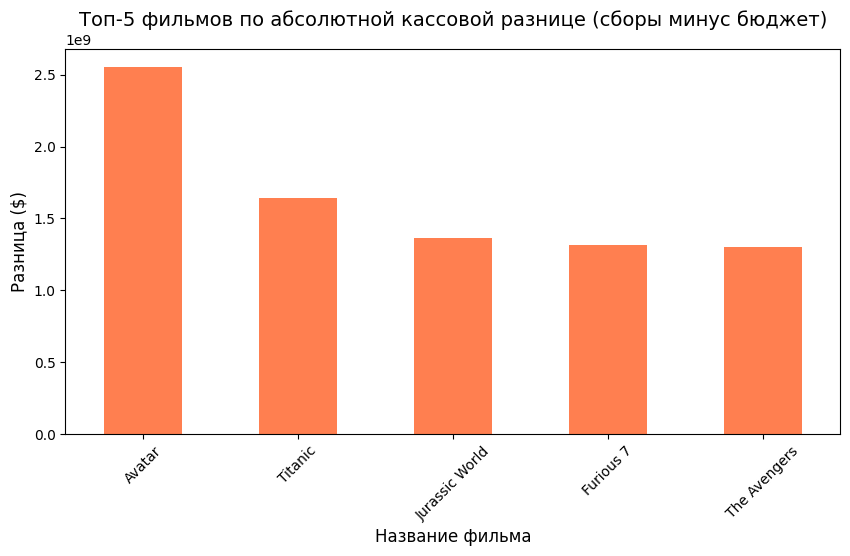

In [31]:
import matplotlib.pyplot as plt
top_5 = top_profitable.head()
top_5.plot(
    kind='bar',
    x='original_title',
    y='profit',
    color='coral',
    figsize=(10, 5),
    legend=False
)
plt.title('Топ-5 фильмов по абсолютной кассовой разнице (сборы минус бюджет)', fontsize=14)
plt.xlabel('Название фильма', fontsize=12)
plt.ylabel('Разница ($)', fontsize=12)

plt.xticks(rotation=45)
plt.show()